In [266]:
import pandas as pd 
import numpy as np
import seaborn as sns # visualizations
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier # cassification problem
from sklearn.model_selection import train_test_split # we split the data to use it well 
from sklearn.metrics import r2_score, accuracy_score, classification_report,confusion_matrix,ConfusionMatrixDisplay # evaluation metric  - R^2 
import matplotlib.pyplot as plt # aids in visualization
from sklearn.model_selection import GridSearchCV

#### **Load Data**

In [267]:
data = load_wine() 

In [268]:
data

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]], shape=(178, 13)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [269]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [270]:
X.head(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0


In [271]:
print(np.unique(y, return_counts=True))

(array([0, 1, 2]), array([59, 71, 48]))


In [272]:
X.shape

(178, 13)

In [273]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.25, random_state=42, stratify=y
)

# 
print(X_train.shape) 
print(X_test.shape) 

(133, 13)
(45, 13)


## **Modeling**

Expression of variance in DTs

In [274]:
def decisionTree(random_state):
    dt_model = DecisionTreeClassifier(random_state = random_state)
    dt_model.fit(X_train, y_train)
    y_dt_predict = dt_model.predict(X_test)
    print(f"accuracy_score: {accuracy_score(y_test, y_dt_predict)}")

In [275]:
decisionTree(50) 

accuracy_score: 0.9777777777777777


In [276]:
decisionTree(2) 

accuracy_score: 0.9777777777777777


In [277]:
decisionTree(42) 

accuracy_score: 0.9555555555555556


In [278]:
decisionTree(65) 

accuracy_score: 0.9111111111111111


In [279]:
decisionTree(99) 

accuracy_score: 0.9777777777777777


Random Forest

In [280]:
rf_model = RandomForestClassifier(
    n_estimators=100, # number of trees
    min_samples_leaf= 13,
    max_features='sqrt', # features considered per split(random in nature)
    max_depth =None, # let the three grow fully 
    bootstrap=True, # settles on bagging approach hence psample is picked with replacement
    oob_score=True,   
    random_state= 42, 
    n_jobs=-1, 
)

In [281]:
rf_model.fit(X_train, y_train) # model training
rf_y_pred = rf_model.predict(X_test) # prediction

## **Evaluation**

In [282]:
print(f" ACCCURACY: {accuracy_score(y_test, rf_y_pred)}")

 ACCCURACY: 0.9555555555555556


In [283]:
print(f" OOB Score: {rf_model.oob_score_}")

 OOB Score: 0.9774436090225563


In [284]:
print(classification_report(y_test, rf_y_pred, target_names= data.target_names))

              precision    recall  f1-score   support

     class_0       0.94      1.00      0.97        15
     class_1       1.00      0.89      0.94        18
     class_2       0.92      1.00      0.96        12

    accuracy                           0.96        45
   macro avg       0.95      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [285]:
cm = confusion_matrix(y_test, rf_y_pred)
cm

array([[15,  0,  0],
       [ 1, 16,  1],
       [ 0,  0, 12]])

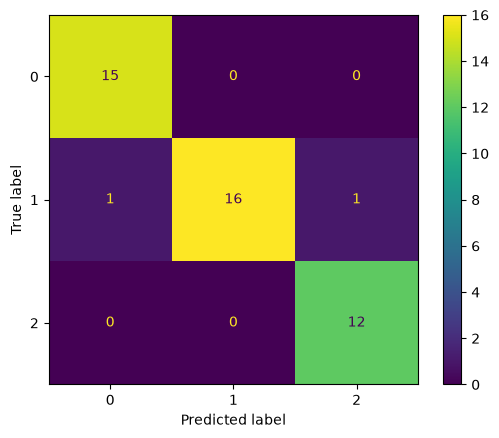

In [286]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot() 
plt.show()

Modellig with GridSearchCV

In [287]:
param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 5,10],
    "max_features":['sqrt', 'log2'],
    "min_samples_leaf":[1,2,4]
}

In [288]:
grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1), 
    param_grid, 
    cv=5, # meant for  cross validation
    scoring="accuracy",
    n_jobs=-1
)

In [289]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",T

In [291]:
print(f"BEST PARAMS: {grid.best_params_}")
print(f"BEST CV accuracy: {grid.best_score_}")

BEST PARAMS: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}
BEST CV accuracy: 0.9698005698005698
